# Phân tích hành vi duyệt web của khách hàng

Notebook này phân tích dữ liệu gốc `online_shoppers_intention.csv` để tìm hiểu hành vi duyệt web của người dùng trước khi họ tạo doanh thu (`Revenue`).

Định hướng phân tích dựa trên tài liệu `data_science` trong Docs MCP, nguồn `Computational and Inferential Thinking`:

- Data science gồm ba hướng chính: exploration, prediction, inference.
- Với phân tích hành vi, notebook này tập trung vào **exploration**.
- Công cụ chính là **thống kê mô tả** và **trực quan hóa** để tìm pattern trong dữ liệu.


## Mục tiêu phân tích

Các câu hỏi chính của notebook gồm:

1. Người dùng mua hàng và không mua hàng khác nhau như thế nào về số trang đã xem và thời lượng duyệt web?
2. Các chỉ số như `BounceRates`, `ExitRates`, `PageValues` liên quan thế nào đến `Revenue`?
3. Tỷ lệ chuyển đổi có khác nhau theo `VisitorType`, `Month`, `Weekend`, `TrafficType` không?
4. Những biến nào có tiềm năng hữu ích nếu tiếp tục xây dựng mô hình dự đoán mua hàng?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)


## 1. Đọc dữ liệu gốc

Dữ liệu được đọc từ file `online_shoppers_intention.csv`. Ở bước này, ta giữ dữ liệu gốc thay vì dùng dữ liệu đã mã hóa hoặc chuẩn hóa, vì các biến như `Month`, `VisitorType`, `Weekend`, `TrafficType`, `BounceRates`, `ExitRates` vẫn còn ý nghĩa diễn giải trực tiếp.

Bộ dữ liệu có 12,330 phiên truy cập và 18 biến. Mỗi dòng tương ứng với một phiên duyệt web, trong đó `Revenue` là biến mục tiêu cho biết phiên đó có tạo doanh thu hay không.

In [3]:
df = pd.read_csv("online_shoppers_intention.csv")

print("Shape:", df.shape)
df.head()


Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## 2. Kiểm tra dữ liệu thiếu và trùng lặp

Trước khi phân tích, cần kiểm tra chất lượng dữ liệu để đảm bảo các kết quả thống kê không bị ảnh hưởng bởi lỗi dữ liệu cơ bản.

Kết quả cho thấy không có giá trị thiếu ở tất cả các cột, do đó không cần xử lý missing values. Dữ liệu có 125 dòng trùng lặp, tương đương khoảng 1.01% tổng số dòng.

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

duplicate_count = df.duplicated().sum()
print("Số dòng trùng lặp:", duplicate_count)
print("Tỷ lệ dòng trùng lặp:", duplicate_count / len(df))


Số dòng trùng lặp: 125
Tỷ lệ dòng trùng lặp: 0.01013787510137875


## 3. Tỷ lệ mua hàng tổng quan

Biến `Revenue` cho biết kết quả của phiên truy cập: `True` là có tạo doanh thu, `False` là không tạo doanh thu.

Tỷ lệ tạo doanh thu toàn bộ dữ liệu là 15.47%, với 1,908 phiên có doanh thu và 10,422 phiên không có doanh thu. Điều này cho thấy dữ liệu bị lệch lớp: phần lớn phiên truy cập không dẫn đến mua hàng.

In [6]:
revenue_counts = df["Revenue"].value_counts().rename(index={False: "No Revenue", True: "Revenue"})
revenue_rate = df["Revenue"].mean()

print("Tỷ lệ tạo doanh thu: {:.2%}".format(revenue_rate))
revenue_counts


Tỷ lệ tạo doanh thu: 15.47%


,count
Revenue,
No Revenue,10422
Revenue,1908


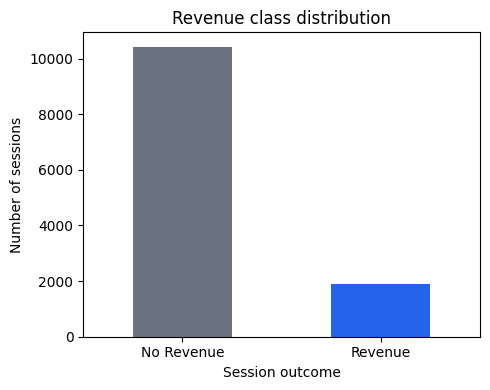

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
revenue_counts.plot(kind="bar", ax=ax, color=["#6B7280", "#2563EB"])
ax.set_title("Revenue class distribution")
ax.set_xlabel("Session outcome")
ax.set_ylabel("Number of sessions")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 4. Tạo thêm biến hành vi duyệt web

Các cột gốc đã có số trang và thời lượng theo từng nhóm trang. Ta tạo thêm vài biến tổng hợp để dễ phân tích:

- `TotalPages`: tổng số trang đã xem.
- `TotalDuration`: tổng thời lượng duyệt web.
- `AvgDurationPerPage`: thời lượng trung bình trên mỗi trang.
- `ProductPageShare`: tỷ lệ trang sản phẩm trong toàn bộ phiên.
- `InfoAdminPageShare`: tỷ lệ trang hành chính/thông tin trong toàn bộ phiên.

Các biến này chỉ phục vụ EDA, không thay thế dữ liệu gốc.


In [8]:
analysis_df = df.copy()

analysis_df["TotalPages"] = (
    analysis_df["Administrative"]
    + analysis_df["Informational"]
    + analysis_df["ProductRelated"]
)
analysis_df["TotalDuration"] = (
    analysis_df["Administrative_Duration"]
    + analysis_df["Informational_Duration"]
    + analysis_df["ProductRelated_Duration"]
)
analysis_df["AvgDurationPerPage"] = np.where(
    analysis_df["TotalPages"] > 0,
    analysis_df["TotalDuration"] / analysis_df["TotalPages"],
    0
)
analysis_df["ProductPageShare"] = np.where(
    analysis_df["TotalPages"] > 0,
    analysis_df["ProductRelated"] / analysis_df["TotalPages"],
    0
)
analysis_df["InfoAdminPageShare"] = np.where(
    analysis_df["TotalPages"] > 0,
    (analysis_df["Administrative"] + analysis_df["Informational"]) / analysis_df["TotalPages"],
    0
)

behavior_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "TotalPages",
    "TotalDuration",
    "AvgDurationPerPage",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "ProductPageShare",
    "InfoAdminPageShare",
]

analysis_df[behavior_cols + ["Revenue"]].head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,TotalPages,TotalDuration,AvgDurationPerPage,BounceRates,ExitRates,PageValues,SpecialDay,ProductPageShare,InfoAdminPageShare,Revenue
0,0,0.0000,0,0.0000,1,0.0000,1,0.0000,0.0000,0.2000,0.2000,0.0000,0.0000,1.0000,0.0000,False
1,0,0.0000,0,0.0000,2,64.0000,2,64.0000,32.0000,0.0000,0.1000,0.0000,0.0000,1.0000,0.0000,False
2,0,0.0000,0,0.0000,1,0.0000,1,0.0000,0.0000,0.2000,0.2000,0.0000,0.0000,1.0000,0.0000,False
3,0,0.0000,0,0.0000,2,2.6667,2,2.6667,1.3333,0.0500,0.1400,0.0000,0.0000,1.0000,0.0000,False
4,0,0.0000,0,0.0000,10,627.5000,10,627.5000,62.7500,0.0200,0.0500,0.0000,0.0000,1.0000,0.0000,False


## 5. Thống kê mô tả hành vi theo Revenue

Phần này so sánh các chỉ số hành vi giữa hai nhóm: phiên không tạo doanh thu và phiên tạo doanh thu. Cả trung bình và trung vị đều được xem xét vì dữ liệu hành vi web thường lệch phải, có một số phiên rất dài hoặc xem rất nhiều trang.

Nhìn chung, các phiên tạo doanh thu có mức độ tương tác cao hơn: số trang đã xem, tổng thời lượng duyệt web, số trang sản phẩm và thời lượng trên trang sản phẩm đều lớn hơn nhóm không tạo doanh thu.

Đặc biệt, `PageValues` có sự khác biệt rất lớn giữa hai nhóm. Trung bình `PageValues` của nhóm tạo doanh thu cao hơn nhiều lần so với nhóm không tạo doanh thu, cho thấy đây là một biến rất quan trọng khi phân biệt khả năng mua hàng.

In [9]:
summary_by_revenue = analysis_df.groupby("Revenue")[behavior_cols].agg(["mean", "median"])
summary_by_revenue


Administrative        Administrative_Duration         Informational  \
                  mean median                    mean  median          mean   
Revenue                                                                       
False           2.1177 0.0000                 73.7401  0.0000        0.4518   
True            3.3936 2.0000                119.4832 52.3667        0.7862   

               Informational_Duration        ProductRelated          \
        median                   mean median           mean  median   
Revenue                                                               
False   0.0000                30.2362 0.0000        28.7146 16.0000   
True    0.0000                57.6114 0.0000        48.2102 29.0000   

        ProductRelated_Duration           TotalPages         TotalDuration  \
                           mean    median       mean  median          mean   
Revenue                                                                      
False                 1069.9878  510.1900    31.2842 18.0000     1173.9642   
True                  1876.2096 1109.9062    52.3899 32.0000     2053.3043   

                  AvgDurationPerPage         BounceRates        ExitRates  \
           median               mean  median        mean median      mean   
Revenue                                                                     
False    588.1667            37.0165 28.2985      0.0253 0.0043    0.0474   
True    1252.0750            42.0283 36.2599      0.0051 0.0000    0.0196   

               PageValues         SpecialDay        ProductPageShare         \
        median       mean  median       mean median             mean median   
Revenue                                                                       
False   0.0286     1.9760  0.0000     0.0684 0.0000           0.9080 0.9750   
True    0.0160    27.2645 16.7581     0.0232 0.0000           0.8895 0.9286   

        InfoAdminPageShare         
                      mean median  
Revenue                            
False               0.0915 0.0250  
True                0.1105 0.0714

In [10]:
mean_diff = analysis_df.groupby("Revenue")[behavior_cols].mean().T
mean_diff.columns = ["No Revenue", "Revenue"]
mean_diff["Revenue / No Revenue"] = mean_diff["Revenue"] / mean_diff["No Revenue"].replace(0, np.nan)
mean_diff.sort_values("Revenue / No Revenue", ascending=False)


,No Revenue,Revenue,Revenue / No Revenue
PageValues,1.9760,27.2645,13.7978
Informational_Duration,30.2362,57.6114,1.9054
ProductRelated_Duration,1069.9878,1876.2096,1.7535
TotalDuration,1173.9642,2053.3043,1.7490
Informational,0.4518,0.7862,1.7399
ProductRelated,28.7146,48.2102,1.6789
TotalPages,31.2842,52.3899,1.6746
Administrative_Duration,73.7401,119.4832,1.6203
Administrative,2.1177,3.3936,1.6025
InfoAdminPageShare,0.0915,0.1105,1.2078


## 6. Phân phối các chỉ số duyệt web quan trọng

Histogram được sử dụng để quan sát phân phối của các biến hành vi như `TotalPages`, `TotalDuration`, `AvgDurationPerPage`, `BounceRates`, `ExitRates` và `PageValues`.

Các biểu đồ cho thấy nhiều biến có phân phối lệch phải: phần lớn phiên truy cập có số trang và thời lượng ở mức thấp hoặc trung bình, trong khi một số ít phiên có giá trị rất cao. Vì vậy, khi trực quan hóa, dữ liệu được cắt ở phân vị 99% để giảm ảnh hưởng của ngoại lệ và giúp biểu đồ dễ đọc hơn.

So sánh giữa hai nhóm cho thấy nhóm tạo doanh thu thường có xu hướng xem nhiều trang hơn, ở lại lâu hơn, có `PageValues` cao hơn, đồng thời có `BounceRates` và `ExitRates` thấp hơn.

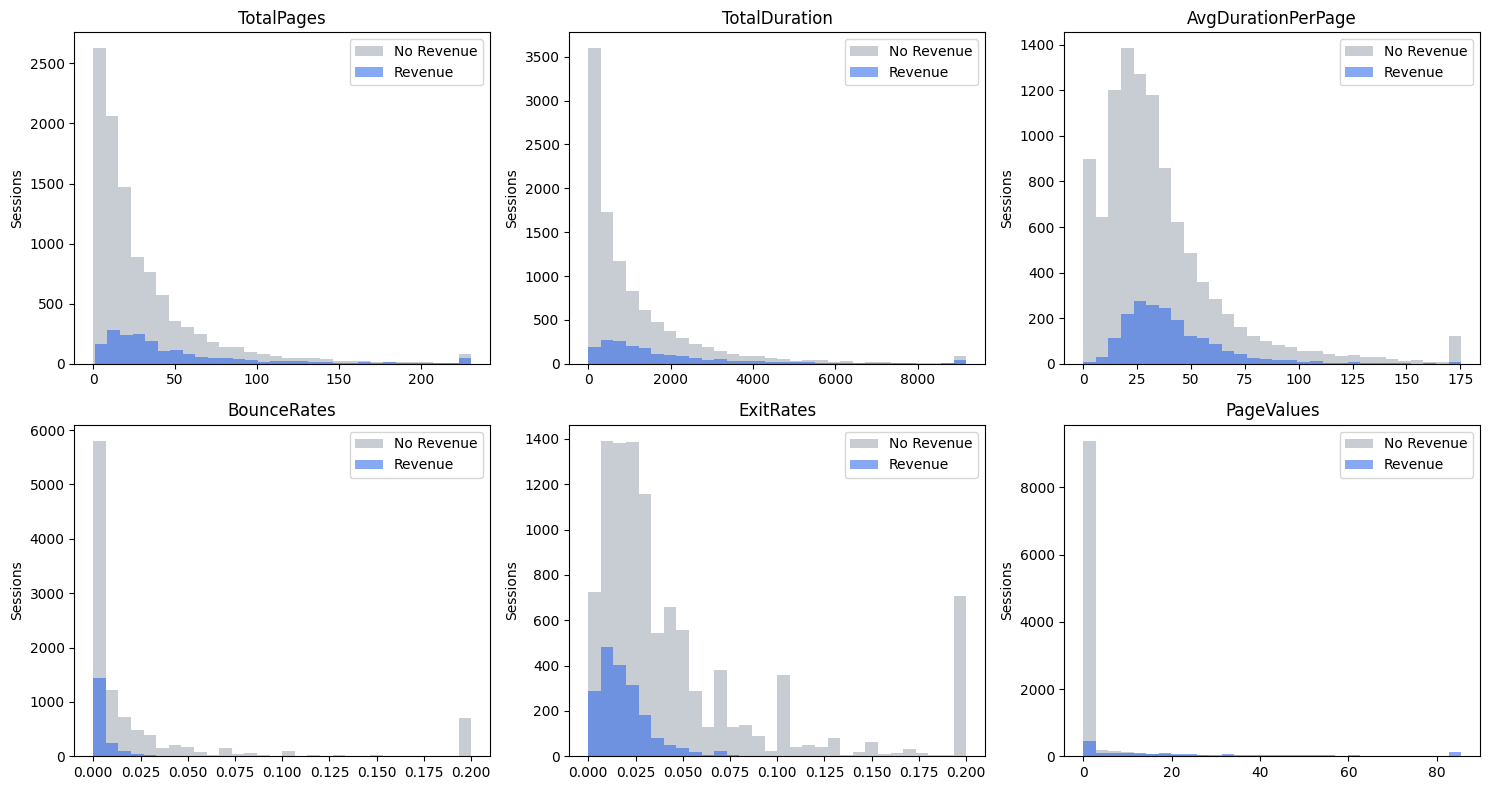

In [11]:
plot_cols = ["TotalPages", "TotalDuration", "AvgDurationPerPage", "BounceRates", "ExitRates", "PageValues"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    no_rev = analysis_df.loc[~analysis_df["Revenue"], col]
    yes_rev = analysis_df.loc[analysis_df["Revenue"], col]
    upper = analysis_df[col].quantile(0.99)
    bins = 30
    ax.hist(no_rev.clip(upper=upper), bins=bins, alpha=0.55, label="No Revenue", color="#9CA3AF")
    ax.hist(yes_rev.clip(upper=upper), bins=bins, alpha=0.55, label="Revenue", color="#2563EB")
    ax.set_title(col)
    ax.set_ylabel("Sessions")
    ax.legend()

plt.tight_layout()
plt.show()


## 7. So sánh median theo nhóm Revenue

Median được dùng để so sánh vì ít bị ảnh hưởng bởi các giá trị ngoại lệ hơn mean. Với dữ liệu hành vi web, median thường phản ánh phiên truy cập “điển hình” tốt hơn.

Kết quả cho thấy phiên tạo doanh thu có median `TotalPages` là 32, cao hơn nhóm không tạo doanh thu là 18. Median `TotalDuration` của nhóm tạo doanh thu cũng cao hơn đáng kể: khoảng 1,252 giây so với 588 giây.

Ngoài ra, nhóm tạo doanh thu có median `ExitRates` thấp hơn và median `PageValues` cao hơn rõ rệt. Điều này củng cố nhận định rằng các phiên mua hàng thường có mức độ tương tác sâu hơn và ít rời khỏi website sớm hơn.

In [12]:
median_compare_cols = ["TotalPages", "TotalDuration", "AvgDurationPerPage", "BounceRates", "ExitRates", "PageValues"]
median_by_revenue = analysis_df.groupby("Revenue")[median_compare_cols].median().T
median_by_revenue.columns = ["No Revenue", "Revenue"]
median_by_revenue


,No Revenue,Revenue
TotalPages,18.0000,32.0000
TotalDuration,588.1667,1252.0750
AvgDurationPerPage,28.2985,36.2599
BounceRates,0.0043,0.0000
ExitRates,0.0286,0.0160
PageValues,0.0000,16.7581


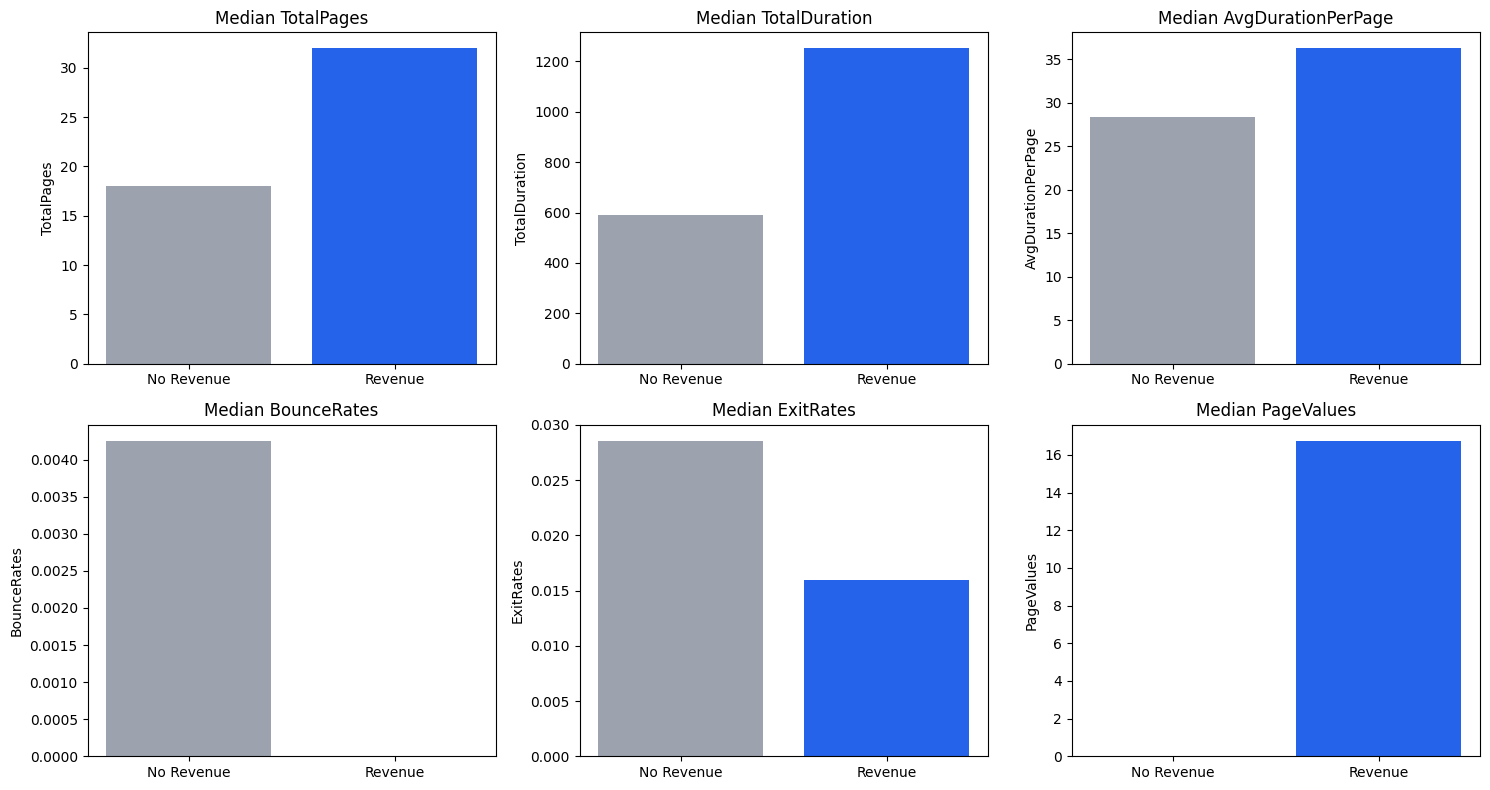

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, median_compare_cols):
    values = analysis_df.groupby("Revenue")[col].median()
    ax.bar(["No Revenue", "Revenue"], values.values, color=["#9CA3AF", "#2563EB"])
    ax.set_title(f"Median {col}")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


# 8 Tỷ lệ chuyển đổi theo TrafficType

Biểu đồ này so sánh tỷ lệ chuyển đổi của 10 nhóm `TrafficType` có số lượng phiên truy cập nhiều nhất.  
Mục tiêu là xác định những nguồn/loại traffic nào có khả năng tạo chuyển đổi tốt hơn, thay vì chỉ xem xét số lượng truy cập.

Từ biểu đồ, `TrafficType = 8` có tỷ lệ chuyển đổi cao nhất, khoảng 27-28%. Các nhóm `TrafficType = 2`, `5`, `10` và `11` cũng có tỷ lệ chuyển đổi tương đối tốt, đều trên khoảng 19%. Ngược lại, `TrafficType = 13` có tỷ lệ chuyển đổi thấp nhất trong nhóm top 10, chỉ khoảng 6%.

Điều này cho thấy không phải nhóm traffic có nhiều phiên truy cập nhất luôn mang lại hiệu quả chuyển đổi cao nhất. Khi đánh giá hiệu quả traffic, cần xem xét đồng thời cả số lượng phiên và tỷ lệ chuyển đổi.

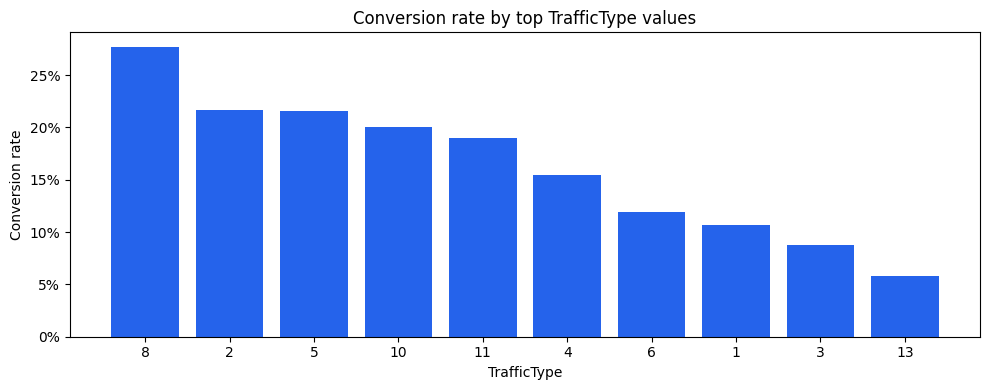

In [ ]:
traffic_conv = conversion_table(analysis_df, "TrafficType")
traffic_conv_top = traffic_conv.sort_values("sessions", ascending=False).head(10).sort_values("conversion_rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(traffic_conv_top["TrafficType"].astype(str), traffic_conv_top["conversion_rate"], color="#2563EB")
ax.set_title("Conversion rate by top TrafficType values")
ax.set_xlabel("TrafficType")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()


## 10. Tương quan với Revenue

Phân tích tương quan được dùng để xem biến số nào có liên hệ tuyến tính mạnh hơn với `Revenue`. Vì `Revenue` là biến boolean, hệ số tương quan ở đây chỉ nên được hiểu như một chỉ báo mô tả, không phải bằng chứng nhân quả.

`PageValues` có tương quan dương mạnh nhất với `Revenue`, khoảng 0.49. Các biến như `TotalPages`, `ProductRelated`, `TotalDuration`, `ProductRelated_Duration` cũng có tương quan dương, cho thấy mức độ tương tác cao hơn thường đi kèm khả năng mua hàng cao hơn.

Ngược lại, `ExitRates` và `BounceRates` có tương quan âm với `Revenue`. Điều này hợp lý về mặt hành vi: nếu người dùng rời trang sớm hoặc thoát phiên nhiều hơn, khả năng tạo doanh thu thường thấp hơn.

In [15]:
def conversion_table(df, col):
    conversion_summary = df.groupby(col)["Revenue"].agg(
        sessions="count",
        converted_sessions="sum"
    ).reset_index()
    conversion_summary["conversion_rate"] = conversion_summary["converted_sessions"] / conversion_summary["sessions"]
    return conversion_summary.sort_values("conversion_rate", ascending=False)

# Tính toán tương quan trước khi dùng
corr = analysis_df.corr(numeric_only=True)

overall_conversion = analysis_df["Revenue"].mean()
median_revenue = analysis_df.groupby("Revenue")[median_compare_cols].median()
monthly_best = conversion_table(analysis_df, "Month").iloc[0]
visitor_best = conversion_table(analysis_df, "VisitorType").iloc[0]
traffic_best = conversion_table(analysis_df, "TrafficType").query("sessions >= 50").iloc[0]
revenue_corr = corr["Revenue"].drop("Revenue").sort_values(ascending=False)

print("Tỷ lệ tạo doanh thu toàn bộ dữ liệu: {:.2%}".format(overall_conversion))
print()
print("Median theo nhóm Revenue:")
display(median_revenue)
print()
print("Tháng có conversion rate cao nhất:", monthly_best["Month"], "-", "{:.2%}".format(monthly_best["conversion_rate"]))
print("VisitorType có conversion rate cao nhất:", visitor_best["VisitorType"], "-", "{:.2%}".format(visitor_best["conversion_rate"]))
print("TrafficType có conversion rate cao nhất trong nhóm >= 50 phiên:", traffic_best["TrafficType"], "-", "{:.2%}".format(traffic_best["conversion_rate"]))
print()
print("Top biến tương quan dương với Revenue:")
display(revenue_corr.head(6))
print()
print("Top biến tương quan âm với Revenue:")
display(revenue_corr.tail(6))

Tỷ lệ tạo doanh thu toàn bộ dữ liệu: 15.47%

Median theo nhóm Revenue:


,TotalPages,TotalDuration,AvgDurationPerPage,BounceRates,ExitRates,PageValues
Revenue,,,,,,
False,18.0000,588.1667,28.2985,0.0043,0.0286,0.0000
True,32.0000,1252.0750,36.2599,0.0000,0.0160,16.7581



Tháng có conversion rate cao nhất: Nov - 25.35%
VisitorType có conversion rate cao nhất: New_Visitor - 24.91%
TrafficType có conversion rate cao nhất trong nhóm >= 50 phiên: 8.0 - 27.70%

Top biến tương quan dương với Revenue:


,Revenue
PageValues,0.4926
TotalPages,0.1641
ProductRelated,0.1585
TotalDuration,0.1561
ProductRelated_Duration,0.1524
Administrative,0.1389



Top biến tương quan âm với Revenue:


,Revenue
Region,-0.0116
OperatingSystems,-0.0147
ProductPageShare,-0.0470
SpecialDay,-0.0823
BounceRates,-0.1507
ExitRates,-0.2071


## 11. Kết luận định hướng

Từ phân tích EDA, có thể rút ra một số kết luận chính:

1. Phần lớn phiên truy cập không tạo doanh thu, tỷ lệ chuyển đổi chỉ khoảng 15.47%.
2. Các phiên tạo doanh thu thường có mức độ tương tác cao hơn: xem nhiều trang hơn, ở lại lâu hơn và có `PageValues` cao hơn.
3. `PageValues` là biến nổi bật nhất khi phân biệt phiên mua hàng và không mua hàng.
4. `BounceRates` và `ExitRates` có quan hệ ngược chiều với khả năng tạo doanh thu.
5. Tỷ lệ chuyển đổi khác nhau theo `Month`, `VisitorType` và `TrafficType`, cho thấy yếu tố thời điểm, loại khách truy cập và nguồn traffic đều đáng được xem xét.

Notebook này chưa kết luận quan hệ nhân quả. Các kết quả nên được hiểu là pattern mô tả ban đầu, có thể dùng để định hướng cho báo cáo và cho bước xây dựng mô hình dự đoán sau này.